# Introduction to Decision Trees: Trying to Predict Which NFL Players Will Be An All-Pro

Welcome! Feel free to edit, play around, and modify these cells to your heart's content—they are for your own experimentation and discovery!

# I. Introduction

What is a better way to kick off the 2026-2027 NFL season with a bit of NFL-related data modeling! For those that are unfamiliar, at the culmination of each NFL season, a series of sports writers, pundits, and other people who spend far too much analyzing, writing, and scrutinizing grown men play a ball sport determine which players at each position were the best, a designation known as **All-Pro**. Now this might seem just like a nice title to have, but this has real financial implications; players often have lucrative incentives in their contract for becoming an All-Pro, they are deciding factors in whether a player will make the Pro Football Hall of Fame, and of course, a focal part of a player's legacy. Thus, it serves to see which types of players become All-Pros and see if we can figure it out before those pretentious sports folks!

They are a lot of nuances in how All-Pros are determined, however for our purposes, we are going to focus on the All-Pros as determined by the **Associated Press**. The Associated Press awards two designations: **First-team All-Pro** and **Second-team All-Pro**, with the former being the absolute best at each position and the latter acting as the runner-up. Also, as you will see later in the notebook, we are going to narrow our focus to a single position to make our modeling process a bit more robust and comprehensive. 

A key focus of this demo will demonstrate that most of work behind machine learning is **not dictated by the complexity of your models** (though that can certainly have a major impact). You will actually spend most of your time modeling **playing around with your data** and ensuring that is filtered down, formatted, and standardized so that your models have the best chance of succeeding. This is why having skills in tools such as Pandas and NumPy are so important; models can change, data manipulation skills will not!

![Image of the Best Quarterback in the NFL, Drake Maye](img/i_love_drake_maye.jpg)

# II. Getting Our Data

Throughout this demo, we will be using data from two primary sources:
- [`nflreadpy`](https://github.com/nflverse/nflreadpy): The Python import of the incredibly popular `nflreadr` package. For a long time, R was the defacto programming language for a lot of visualization and data work with Python, but with packages like this, Python is slowly catching up. With this, we can pull play-by-play data, season statistics, advanced NextGenStats, and a ton of more information!
- CSV exports from [`pro-football-reference.com`](https://www.pro-football-reference.com): Pro-football-reference.com is one of the most popular archives of NFL data around, and has been that way for decades. However, they understandably don't have an API and have severe restrictions around web scraping to protect the information they work so hard to obtain. However, they do have static exports of their data that we can painstankingly download and save. Luckily for you, I already did most of this work for you to get which players were All-Pros since 2015. All of this data can be found in the `data` folder. 

In [1]:
# Most of you likely won't have these packages installed, so let's download this:
# !pip install nflreadpy pyarrow polars plotly

# If you need some of the other dependencies we are working with
# !pip install pandas scikit-learn numpy matplotlib 

In [2]:
# Our imports!
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import plotly.express as px
import matplotlib.pyplot as plt
import nflreadpy as nfl
import glob

## II.I Getting our Player Statistic Data

Let's load in the stats for the seasons we are looking at (since 2010), both the play-by-play stats and also some advanced analytics.

I highly encourage you to reference the nflreadpy package as you do this, with documentation [available here](https://nflreadpy.nflverse.com)

In [3]:
# Let's first get the necessary data we need from nflreadpy

# This is to get player stats from 2010. 

# We could do it like this:
# player_stats = nfl.load_player_stats([2010, 2011, 2012, 2013,...])

# But that is so slow! Let's do this instead:
seasons: list[str] = [year for year in range(2016, 2026)]
player_stats: pd.DataFrame = nfl.load_player_stats(seasons, summary_level = "reg").to_pandas()

In [4]:
# Let's take a look at our data!
player_stats.head(5)

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,season_type,recent_team,games,...,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,fantasy_points,fantasy_points_ppr
0,00-0004091,P.Dawson,Phil Dawson,K,SPEC,https://static.www.nfl.com/image/private/f_aut...,2016,REG,SF,16,...,0,0,0,0,0,0,0,0,0.00,0.00
1,00-0016919,A.Vinatieri,Adam Vinatieri,K,SPEC,https://static.www.nfl.com/image/private/f_aut...,2016,REG,IND,16,...,0,0,0,0,0,0,0,0,0.00,0.00
2,00-0019596,T.Brady,Tom Brady,QB,QB,https://static.www.nfl.com/image/private/f_aut...,2016,REG,NE,12,...,0,0,0,0,0,0,0,0,258.56,258.56
3,00-0019646,S.Janikowski,Sebastian Janikowski,K,SPEC,https://static.www.nfl.com/image/private/f_aut...,2016,REG,LV,16,...,0,0,0,0,0,0,0,0,0.00,0.00
4,00-0019714,S.Lechler,Shane Lechler,P,SPEC,https://static.www.nfl.com/image/private/f_aut...,2016,REG,HOU,16,...,5,3,3,13,48,477,1,2886,0.00,0.00


In [5]:
# We can start manipulating this how we want and exploring for example:
player_stats.loc[
    (player_stats["position"] == "QB") & (player_stats["attempts"] >= 400)
].sort_values(by="passing_cpoe", ascending=False).head(3)

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,season_type,recent_team,games,...,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,fantasy_points,fantasy_points_ppr
19165,00-0039851,D.Maye,Drake Maye,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2025,REG,NE,17,...,0,0,0,0,0,0,0,0,350.96,351.96
4085,00-0029263,R.Wilson,Russell Wilson,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2018,REG,SEA,16,...,0,0,0,0,0,0,0,0,298.42,299.42
7511,00-0023459,A.Rodgers,Aaron Rodgers,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2020,REG,GB,16,...,0,0,0,0,0,0,0,0,382.26,383.26


In [6]:
# Let's get a sense of our data at a macro-level
display(player_stats.describe())

print(f"The number of rows in our Player Stats Data: {player_stats.shape[0]:,}")
print(f"The number of columns in our Census Data: {player_stats.shape[1]}")

# Print our columns in a nice 5x5 list
print(
    f"These are the columns within our dataset: \n{'\n'.join([f'{', '.join(player_stats.columns[i:i+5])}' for i in range(0, len(player_stats.columns), 5)])}"
)

,season,games,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,...,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,fantasy_points,fantasy_points_ppr
count,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,...,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000,19531.000000
mean,2020.579847,9.054324,5.903948,9.199222,65.589012,0.409912,0.211152,0.642978,-4.268087,0.084737,...,0.111054,0.142235,0.074548,0.302852,0.468230,4.154831,0.003891,45.164917,17.335803,23.239750
std,2.857104,7.918845,40.692602,62.656822,455.881234,3.032815,1.439641,4.382315,29.287339,0.630865,...,0.967154,1.167377,0.633808,2.415851,3.686603,34.139160,0.070730,349.137834,47.281631,58.995493
min,2016.000000,1.000000,0.000000,0.000000,-7.000000,0.000000,0.000000,0.000000,-477.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-4.800000,-4.800000
25%,2018.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2023.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.100000,5.500000
max,2025.000000,272.000000,490.000000,733.000000,5316.000000,50.000000,30.000000,68.000000,0.000000,11.000000,...,18.000000,20.000000,11.000000,41.000000,59.000000,655.000000,3.000000,4508.000000,430.380000,471.200000


The number of rows in our Player Stats Data: 19,531
The number of columns in our Census Data: 148
These are the columns within our dataset: 
player_id, player_name, player_display_name, position, position_group
headshot_url, season, season_type, recent_team, games
completions, attempts, passing_yards, passing_tds, passing_interceptions
sacks_suffered, sack_yards_lost, sack_fumbles, sack_fumbles_lost, passing_air_yards
passing_yards_after_catch, passing_first_downs, passing_epa, passing_cpoe, passing_2pt_conversions
pacr, passing_10, passing_16, passing_20, passing_40
carries, rushing_yards, rushing_tds, rushing_fumbles, rushing_fumbles_lost
rushing_first_downs, rushing_epa, rushing_2pt_conversions, rushing_10, rushing_12
rushing_20, rushing_40, receptions, targets, receiving_yards
receiving_tds, receiving_fumbles, receiving_fumbles_lost, receiving_air_yards, receiving_yards_after_catch
receiving_first_downs, receiving_epa, receiving_2pt_conversions, receiving_10, receiving_16
receiving

In [14]:
# Instead, we can narrow this down to just receivers. 
# We also need to set our index to `player_display_name` and `season` as these are unique values 
receiver_stats: pd.DataFrame = player_stats.loc[
    player_stats['position'] == 'WR'
].reset_index()

# Let's check the updated counts of our dataframe
print(f"The number of rows in our Player Stats Data: {receiver_stats.shape[0]:,}")
print(f"The number of columns in our Census Data: {receiver_stats.shape[1]}")
receiver_stats.head(5)

The number of rows in our Player Stats Data: 2,312
The number of columns in our Census Data: 149


,index,player_id,player_name,player_display_name,position,position_group,headshot_url,season,season_type,recent_team,...,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,fantasy_points,fantasy_points_ppr
0,5,00-0020337,S.Smith,Steve Smith,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2016,REG,BAL,...,0,0,0,0,0,0,0,0,113.9,183.9
1,18,00-0022044,A.Johnson,Andre Johnson,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2016,REG,TEN,...,0,0,0,0,0,0,0,0,20.5,29.5
2,21,00-0022084,A.Boldin,Anquan Boldin,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2016,REG,DET,...,0,0,0,0,0,0,0,0,106.4,173.4
3,34,00-0022921,L.Fitzgerald,Larry Fitzgerald,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2016,REG,ARI,...,0,0,0,0,0,0,0,0,136.8,243.8
4,56,00-0023496,V.Jackson,Vincent Jackson,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2016,REG,TB,...,0,0,0,0,0,0,0,0,17.3,32.3


In [16]:
# Let's select the important columns we need for receivers
# These are the columns:
"""
    "player_id",
    "season",
    "player_display_name",
    "targets",
    "receptions",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_fumbles_lost",
    "receiving_epa",
    "racr", # This is a ratio for the number of receiving yards per air yards targeted per game
    "target_share",
    "wopr"  # Weighted Opportunity Rating (combines target share and air yard share into one metric)
"""
receiver_stats: pd.DataFrame = receiver_stats[[
    "player_id",
    "season",
    "player_display_name",
    "targets",
    "receptions",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_fumbles_lost",
    "receiving_epa",
    "racr", # This is a ratio for the number of receiving yards per air yards targeted per game
    "target_share",
    "wopr"  # Weighted Opportunity Rating (combines target share and air yard share into one metric)
]]

receiver_stats.head(5)

,player_id,season,player_display_name,targets,receptions,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_fumbles_lost,receiving_epa,racr,target_share,wopr
0,00-0020337,2016,Steve Smith,101,70,799,5,873,281,0,37.947165,0.915235,0.151880,0.349021
1,00-0022044,2016,Andre Johnson,23,9,85,2,268,15,0,-2.164626,0.317164,0.046939,0.109903
2,00-0022084,2016,Anquan Boldin,95,67,584,8,546,231,0,28.075429,1.069597,0.163793,0.332141
3,00-0022921,2016,Larry Fitzgerald,150,107,1023,6,1150,358,1,30.592934,0.889565,0.235849,0.483529
4,00-0023496,2016,Vincent Jackson,32,15,173,0,435,16,0,-6.982121,0.397701,0.056042,0.136392


In [17]:
# We can also find data from next-gen stats to add an extra level of nuance to our data
next_gen_stats: pd.DataFrame = nfl.load_nextgen_stats(
    seasons, stat_type="receiving"
).to_pandas().reset_index()

next_gen_stats.head(5)

,index,season,season_type,week,player_display_name,player_position,team_abbr,avg_cushion,avg_separation,avg_intended_air_yards,...,yards,rec_touchdowns,avg_yac,avg_expected_yac,avg_yac_above_expectation,player_gsis_id,player_first_name,player_last_name,player_jersey_number,player_short_name
0,0,2016,REG,0,Tyreek Hill,WR,KC,7.822639,3.518714,7.870602,...,599.0,6,4.670656,5.331570,-0.660915,00-0033040,Tyreek,Hill,10,T.Hill
1,1,2016,REG,0,Richard Rodgers,TE,GB,7.605789,2.693882,8.381277,...,271.0,2,3.347667,3.274428,0.073239,00-0031384,Richard,Rodgers,82,NaN
2,2,2016,REG,0,Travis Benjamin,WR,LAC,7.601111,3.017426,13.329867,...,677.0,4,5.679362,4.968711,0.710651,00-0029269,Travis,Benjamin,12,NaN
3,3,2016,REG,0,Cordarrelle Patterson,WR,MIN,7.466269,3.230445,5.564000,...,453.0,2,6.278462,5.619060,0.659402,00-0030578,Cordarrelle,Patterson,84,C.Patterson
4,4,2016,REG,0,DeSean Jackson,WR,WAS,7.295833,2.886285,16.035400,...,1005.0,4,4.867143,5.051773,-0.184630,00-0026189,DeSean,Jackson,11,D.Jackson


In [18]:
# Our data is given to us per-week, but we can find regular season summary by filtering week == 0
next_gen_stats = next_gen_stats.loc[next_gen_stats['week'] == 0]

# Some of these columns overlap with our other dataset, so let's just keep the things we need
next_gen_stats = next_gen_stats[[
    "player_gsis_id",
    "player_display_name",
    "season",
    "avg_cushion",
    "avg_separation",
    "avg_intended_air_yards",
    "percent_share_of_intended_air_yards",
    "catch_percentage",
    "avg_yac",
    "avg_expected_yac",
    "avg_yac_above_expectation",
]]

next_gen_stats.head(5)

,player_gsis_id,player_display_name,season,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,catch_percentage,avg_yac,avg_expected_yac,avg_yac_above_expectation
0,00-0033040,Tyreek Hill,2016,7.822639,3.518714,7.870602,16.708058,73.493976,4.670656,5.331570,-0.660915
1,00-0031384,Richard Rodgers,2016,7.605789,2.693882,8.381277,6.884246,63.829787,3.347667,3.274428,0.073239
2,00-0029269,Travis Benjamin,2016,7.601111,3.017426,13.329867,19.536131,62.666667,5.679362,4.968711,0.710651
3,00-0030578,Cordarrelle Patterson,2016,7.466269,3.230445,5.564000,9.530008,74.285714,6.278462,5.619060,0.659402
4,00-0026189,DeSean Jackson,2016,7.295833,2.886285,16.035400,28.085914,56.000000,4.867143,5.051773,-0.184630


We want to join these two dataframes together, which we can do through the very powerful `pd.DataFrame.merge()` method! Merges & Joins are arguably the most powerful tool in your data manipulation arsenal and can allow you to combine multiple datasets together in highly-complex and nuanced ways. 

*What is the difference between a `join` and a `merge`? You can find out more [here](https://www.shanelynn.ie/merge-join-dataframes-python-pandas-index-1/)*

We'll do a `left` merge to combine `receiving_stats` with `next_gen_stats`, using the `player_gsis_id` column as our key. This means every row from `receiving_stats` will be kept, and we'll add matching info from `next_gen_stats` where it exists.

![Gif of a Left Join](https://miro.medium.com/v2/resize:fit:1344/1*a3qrRVc7b5VddMTsHLm2dw.gif) \
*Courtesy of [this Medium Article](https://medium.com/analytics-vidhya/everything-about-pandas-100-code-snippets-and-tricks-443e5ae59e81) by Senthil E*

In [19]:
# Let's perform our join
# Question: Why is it problematic if we join just on the name of each player?
combined_receiver_stats: pd.DataFrame = receiver_stats.merge(
    right = next_gen_stats, # The other dataframe we would like to merge on
    left_on = ['player_id', 'season'], # The names of the column in the left dataframe we would like to merge on
    right_on = ['player_gsis_id', 'season'], # The names of the column in the right dataframe we would like to merge on
    how = "left", # The type of join we would like to do
)

display(combined_receiver_stats)

print(
    f"These are the columns within our dataset: \n{'\n'.join([f'{', '.join(combined_receiver_stats.columns[i:i+5])}' for i in range(0, len(combined_receiver_stats.columns), 5)])}"
)

,player_id,season,player_display_name_x,targets,receptions,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_fumbles_lost,...,player_gsis_id,player_display_name_y,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,catch_percentage,avg_yac,avg_expected_yac,avg_yac_above_expectation
0,00-0020337,2016,Steve Smith,101,70,799,5,873,281,0,...,00-0020337,Steve Smith,6.503258,2.659960,9.094158,17.493096,69.306931,3.815857,3.158380,0.657477
1,00-0022044,2016,Andre Johnson,23,9,85,2,268,15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00-0022084,2016,Anquan Boldin,95,67,584,8,546,231,0,...,00-0022084,Anquan Boldin,5.176517,2.409151,6.720842,13.521389,70.526316,3.130299,3.469019,-0.338721
3,00-0022921,2016,Larry Fitzgerald,150,107,1023,6,1150,358,1,...,00-0022921,Larry Fitzgerald,6.482463,2.361345,7.994867,18.062107,71.333333,3.429720,3.625196,-0.195477
4,00-0023496,2016,Vincent Jackson,32,15,173,0,435,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2307,00-0040705,2025,Chimere Dike,74,48,423,4,599,220,0,...,00-0040705,Chimere Dike,6.767761,3.849094,8.170676,15.565235,64.864865,4.811667,5.064533,-0.252866
2308,00-0040727,2025,Tre Harris,43,30,324,1,398,139,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2309,00-0040729,2025,Jack Bech,29,20,224,0,240,68,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2310,00-0040735,2025,Luther Burden III,60,47,652,2,460,334,0,...,00-0040735,Luther Burden,7.328824,4.624625,7.280667,9.738220,78.333333,7.397660,6.465753,0.931907


These are the columns within our dataset: 
player_id, season, player_display_name_x, targets, receptions
receiving_yards, receiving_tds, receiving_air_yards, receiving_yards_after_catch, receiving_fumbles_lost
receiving_epa, racr, target_share, wopr, player_gsis_id
player_display_name_y, avg_cushion, avg_separation, avg_intended_air_yards, percent_share_of_intended_air_yards
catch_percentage, avg_yac, avg_expected_yac, avg_yac_above_expectation


In [20]:
# Some column cleanup after our merge
combined_receiver_stats = combined_receiver_stats.drop(columns=['player_gsis_id', 'player_display_name_y'])
combined_receiver_stats = combined_receiver_stats.rename(columns={'player_display_name_x': 'player_display_name'})

# Not all of our receivers have advanced NextGenStats data, so we ought to remove them
combined_receiver_stats = combined_receiver_stats.loc[combined_receiver_stats['avg_separation'].notna()]

combined_receiver_stats

,player_id,season,player_display_name,targets,receptions,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_fumbles_lost,...,target_share,wopr,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,catch_percentage,avg_yac,avg_expected_yac,avg_yac_above_expectation
0,00-0020337,2016,Steve Smith,101,70,799,5,873,281,0,...,0.151880,0.349021,6.503258,2.659960,9.094158,17.493096,69.306931,3.815857,3.158380,0.657477
2,00-0022084,2016,Anquan Boldin,95,67,584,8,546,231,0,...,0.163793,0.332141,5.176517,2.409151,6.720842,13.521389,70.526316,3.130299,3.469019,-0.338721
3,00-0022921,2016,Larry Fitzgerald,150,107,1023,6,1150,358,1,...,0.235849,0.483529,6.482463,2.361345,7.994867,18.062107,71.333333,3.429720,3.625196,-0.195477
6,00-0024334,2016,Brandon Marshall,128,59,788,3,1602,176,0,...,0.234432,0.580412,4.439597,2.215873,13.628047,33.233503,46.093750,2.964915,4.734116,-1.769200
8,00-0025396,2016,Ted Ginn,95,54,752,4,1169,182,0,...,0.171790,0.400970,6.765000,2.992979,13.388737,20.933329,56.842105,3.403333,4.053029,-0.649696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274,00-0040130,2025,Jayden Higgins,68,41,525,6,839,123,0,...,0.122966,0.307701,5.740000,2.689252,12.037941,17.968891,60.294118,3.255122,3.310782,-0.055660
2276,00-0040134,2025,Pat Bryant,49,31,378,1,410,147,0,...,0.083904,0.189804,6.332708,2.438727,8.667143,9.690521,63.265306,4.807419,3.991368,0.816051
2280,00-0040170,2025,Elic Ayomanor,89,41,515,4,1126,115,0,...,0.167925,0.448250,5.832892,2.666566,12.259888,28.089402,46.067416,3.039024,3.286176,-0.247151
2307,00-0040705,2025,Chimere Dike,74,48,423,4,599,220,0,...,0.139623,0.313893,6.767761,3.849094,8.170676,15.565235,64.864865,4.811667,5.064533,-0.252866


# II.II: Loading Our All-Pro Data

Take a look at the `data` folder that is within this repository, you should see a bunch of files that look like:

- `all-pro-players-2010.csv`
- `all-pro-players-2011.csv`
- `all-pro-players-2012.csv`
- ...

Now, we need to load all these *distinct* CSV files into Pandas; how do we do that?

In [21]:
"""
We could do this:
all_pro_players_2010 = pd.read_csv("data/all-pro-players-2010.csv")
all_pro_players_2011 = pd.read_csv("data/all-pro-players-2011.csv)

But that will take forever! Let's find another way
"""

'\nWe could do this:\nall_pro_players_2010 = pd.read_csv("data/all-pro-players-2010.csv")\nall_pro_players_2011 = pd.read_csv("data/all-pro-players-2011.csv)\n\nBut that will take forever! Let\'s find another way\n'

To accomplish this, we will take advantage of a nifty computational operator called a **wildcard operator** or **\***. Suppose you have a bunch of files that look like:

- `file_1`
- `file_2`
- `file_3`
- `not_a_file_1`
- `not_a_file_2`

And we only want the things that begin with `file`. A wildcard operator written like `file-*` will be able to find those files effortlessly without having to laboriously specify each distinct file by name. Pretty neat!

To do this in Python, we will use that `glob` dependency that we imported earlier. Let's take a look:

In [22]:
# Using glob and the wildcard operator, we can find all of the CSV files that match our `all-pro-players` format
path_to_our_data: str = "data/all-pro-players-*.csv"

try:
    all_pro_files: list[str] = glob.glob(path_to_our_data)
    if not all_pro_files:
        raise FileNotFoundError(
            f"No files found matching the pattern {path_to_our_data}. "
            "Please check that the data directory and all-pro CSV files exist."
        )
except Exception as e:
    print(f"Error occurred while searching for files: {e}")
    all_pro_files = []

print(all_pro_files)

['data\\all-pro-players-2010.csv', 'data\\all-pro-players-2011.csv', 'data\\all-pro-players-2012.csv', 'data\\all-pro-players-2013.csv', 'data\\all-pro-players-2014.csv', 'data\\all-pro-players-2015.csv', 'data\\all-pro-players-2016.csv', 'data\\all-pro-players-2017.csv', 'data\\all-pro-players-2018.csv', 'data\\all-pro-players-2019.csv', 'data\\all-pro-players-2020.csv', 'data\\all-pro-players-2021.csv', 'data\\all-pro-players-2022.csv', 'data\\all-pro-players-2023.csv', 'data\\all-pro-players-2024.csv', 'data\\all-pro-players-2025.csv']


In [23]:
# Let's convert all of this data into Pandas Dataframes
all_pro_players: list[pd.DataFrame] = [pd.read_csv(all_pro_data) for all_pro_data in all_pro_files]

In [24]:
# Right now, these are all distinct dataframes, let's combine them together for easy filtering
all_pro_players: pd.DataFrame = pd.concat(all_pro_players, ignore_index=True)
display(all_pro_players.head(5))
print(
    f"These are the columns within our dataset: \n{'\n'.join([f'{', '.join(all_pro_players.columns[i:i+5])}' for i in range(0, len(all_pro_players.columns), 5)])}"
)

,Pos,Player,Tm,Age,Yrs,G,GS,Cmp,Att,Yds,...,TD.1,Rec,Yds.2,TD.2,Solo,Sk,Int.1,All-pro teams,Player-additional,Year
0,QB,Tom Brady,NWE,33,10,16,16,324,492,3900,...,1,0,0,0,0.0,0.0,0,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm SN:...,BradTo00,2010
1,QB,Matt Ryan,ATL,25,2,16,16,357,571,3705,...,0,0,0,0,0.0,0.0,0,PFF: 1st Tm,RyanMa00,2010
2,QB,Michael Vick,PHI,30,9,12,12,233,372,3018,...,9,0,0,0,0.0,0.0,0,FW: 1st Tm All-Conf.,VickMi00,2010
3,QB,Aaron Rodgers,GNB,27,5,15,15,312,475,3922,...,4,0,0,0,0.0,0.0,0,PFF: 2nd Tm,RodgAa00,2010
4,RB,Jamaal Charles,KAN,24,2,16,6,0,0,0,...,5,45,468,3,0.0,0.0,0,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,CharJa00,2010


These are the columns within our dataset: 
Pos, Player, Tm, Age, Yrs
G, GS, Cmp, Att, Yds
TD, Int, Att.1, Yds.1, TD.1
Rec, Yds.2, TD.2, Solo, Sk
Int.1, All-pro teams, Player-additional, Year


In [25]:
# Let's do some similar steps to what we do above for the player stats: just get the wide receivers and just select the columns we need
all_pro_receivers: pd.DataFrame = all_pro_players.loc[
    (all_pro_players["Pos"] == "WR") & (all_pro_players["Year"] >= seasons[0])
].reset_index()

all_pro_receivers = all_pro_receivers[["Player", "All-pro teams", "Year"]]

all_pro_receivers.head(5)

,Player,All-pro teams,Year
0,Julio Jones,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2016
1,Antonio Brown,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2016
2,Mike Evans,PFF: 1st Tm AP: 2nd Tm,2016
3,Odell Beckham Jr.,FW: 1st Tm All-Conf. AP: 2nd Tm PFF: 2nd Tm,2016
4,T.Y. Hilton,FW: 1st Tm All-Conf. PFF: 2nd Tm,2016


This is great! But remember, earlier we said we are just focused on All-Pros as designated by the Associated Press (AP). However, this dataset includes people from different sources (such as Pro Football Focus, PFF, and Pro Football Writers of America, FW). To get around this, we will need to do some more filtering to just extract the AP designations and what specifically those designations are (1st Team or 2nd Team). 

In [26]:
# We need to do per-column string filtering in Pandas, which can be a little weird at first but is very powerful!
all_pro_receivers['is_ap_in_column'] = all_pro_receivers['All-pro teams'].str.contains('AP:')

all_pro_receivers

,Player,All-pro teams,Year,is_ap_in_column
0,Julio Jones,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2016,True
1,Antonio Brown,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2016,True
2,Mike Evans,PFF: 1st Tm AP: 2nd Tm,2016,True
3,Odell Beckham Jr.,FW: 1st Tm All-Conf. AP: 2nd Tm PFF: 2nd Tm,2016,True
4,T.Y. Hilton,FW: 1st Tm All-Conf. PFF: 2nd Tm,2016,False
...,...,...,...,...
63,Ja'Marr Chase,FW: 1st Tm All-Conf. AP: 1st Tm PFF: 2nd Tm,2025,True
64,Amon-Ra St. Brown,AP: 2nd Tm PFF: 1st Tm,2025,True
65,Nico Collins,FW: 1st Tm All-Conf. PFF: 2nd Tm,2025,False
66,George Pickens,AP: 2nd Tm PFF: 2nd Tm,2025,True


In [27]:
# Great! Now once we know if AP is in a column, we can take this a step further and extract the text if AP exists
# To do this, we will use Regular Expressions (RegEx), which is a very common string pattern matching tool 
all_pro_receivers['ap_designation'] = all_pro_receivers['All-pro teams'].str.extract(r'AP: (.{6})')

all_pro_receivers.head(10)

,Player,All-pro teams,Year,is_ap_in_column,ap_designation
0,Julio Jones,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2016,True,1st Tm
1,Antonio Brown,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2016,True,1st Tm
2,Mike Evans,PFF: 1st Tm AP: 2nd Tm,2016,True,2nd Tm
3,Odell Beckham Jr.,FW: 1st Tm All-Conf. AP: 2nd Tm PFF: 2nd Tm,2016,True,2nd Tm
4,T.Y. Hilton,FW: 1st Tm All-Conf. PFF: 2nd Tm,2016,False,NaN
5,Antonio Brown,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2017,True,1st Tm
6,DeAndre Hopkins,FW: 1st Tm All-Conf. AP: 1st Tm FW: 1st Tm PFF...,2017,True,1st Tm
7,Julio Jones,FW: 1st Tm All-Conf. AP: 2nd Tm PFF: 1st Tm SN...,2017,True,2nd Tm
8,Michael Thomas,FW: 1st Tm All-Conf. PFF: 2nd Tm,2017,False,NaN
9,Adam Thielen,AP: 2nd Tm,2017,True,2nd Tm


In [28]:
# Let's filter down our dataset now to just the receivers that were designated an All-Pro by the Associated Press
print(f"We currently have {len(all_pro_receivers)} receivers in our dataset")
all_pro_receivers_ap = all_pro_receivers.loc[
    all_pro_receivers["ap_designation"].notna()
][["Player", "Year", "ap_designation"]]
display(all_pro_receivers_ap.head(10))
print(f"We currently have {len(all_pro_receivers_ap)} receivers in our dataset")

We currently have 68 receivers in our dataset


,Player,Year,ap_designation
0,Julio Jones,2016,1st Tm
1,Antonio Brown,2016,1st Tm
2,Mike Evans,2016,2nd Tm
3,Odell Beckham Jr.,2016,2nd Tm
5,Antonio Brown,2017,1st Tm
6,DeAndre Hopkins,2017,1st Tm
7,Julio Jones,2017,2nd Tm
9,Adam Thielen,2017,2nd Tm
11,DeAndre Hopkins,2018,1st Tm
12,Michael Thomas,2018,1st Tm


We currently have 54 receivers in our dataset


## II.III Combining our Data Together

Now that we have both our datasets, we can combine them together and get to some modeling afterwards!

In [29]:
# Just for standardization, I am going to create temporary versions of our player name columns to ensure that there is no funky capitalization
combined_receiver_stats['name_standard'] = combined_receiver_stats['player_display_name'].str.lower()
all_pro_receivers_ap['name_standard'] = all_pro_receivers_ap['Player'].str.lower()

In [30]:
# Let's combine our columns together!
df: pd.DataFrame = combined_receiver_stats.merge(
    right = all_pro_receivers_ap, # The other dataframe we would like to merge on 
    left_on = ["name_standard", "season"],
    right_on = ["name_standard", "Year"],
    how = "left"
)

# Let's drop some of these extra columns we don't need
df = df.drop(columns=["Player", "Year", "name_standard"])

# Let's fill in Players Who are Not All Pros with a more descriptive name
df['ap_designation'] = df['ap_designation'].fillna('Not AP')

In [31]:
df

,player_id,season,player_display_name,targets,receptions,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_fumbles_lost,...,wopr,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,catch_percentage,avg_yac,avg_expected_yac,avg_yac_above_expectation,ap_designation
0,00-0020337,2016,Steve Smith,101,70,799,5,873,281,0,...,0.349021,6.503258,2.659960,9.094158,17.493096,69.306931,3.815857,3.158380,0.657477,Not AP
1,00-0022084,2016,Anquan Boldin,95,67,584,8,546,231,0,...,0.332141,5.176517,2.409151,6.720842,13.521389,70.526316,3.130299,3.469019,-0.338721,Not AP
2,00-0022921,2016,Larry Fitzgerald,150,107,1023,6,1150,358,1,...,0.483529,6.482463,2.361345,7.994867,18.062107,71.333333,3.429720,3.625196,-0.195477,Not AP
3,00-0024334,2016,Brandon Marshall,128,59,788,3,1602,176,0,...,0.580412,4.439597,2.215873,13.628047,33.233503,46.093750,2.964915,4.734116,-1.769200,Not AP
4,00-0025396,2016,Ted Ginn,95,54,752,4,1169,182,0,...,0.400970,6.765000,2.992979,13.388737,20.933329,56.842105,3.403333,4.053029,-0.649696,Not AP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,00-0040130,2025,Jayden Higgins,68,41,525,6,839,123,0,...,0.307701,5.740000,2.689252,12.037941,17.968891,60.294118,3.255122,3.310782,-0.055660,Not AP
927,00-0040134,2025,Pat Bryant,49,31,378,1,410,147,0,...,0.189804,6.332708,2.438727,8.667143,9.690521,63.265306,4.807419,3.991368,0.816051,Not AP
928,00-0040170,2025,Elic Ayomanor,89,41,515,4,1126,115,0,...,0.448250,5.832892,2.666566,12.259888,28.089402,46.067416,3.039024,3.286176,-0.247151,Not AP
929,00-0040705,2025,Chimere Dike,74,48,423,4,599,220,0,...,0.313893,6.767761,3.849094,8.170676,15.565235,64.864865,4.811667,5.064533,-0.252866,Not AP


With all of your data combined, we have successfully created a rich dataset that is well-suited for modeling. We have a series of independent variables (our receiving stats) and dependent variable (AP Designation) to now begin modeling. But, before we go there, let's visualize our data to make sure we fully understand the implications of modeling.

![Summary of our Data Pre-Processing Steps](./img/our_data_fig.png)

# II. Visualizations

In [32]:
# Really quick, let's get a sense of our data before modeling by creating some quick visualizations!

# First, the receivers with the most receiving yards in our dataset
# Important: the same player can appear in multiple seasons, so if we plot just on
# player name, Plotly treats those rows as one x-category and stacks the bars.
# Make each bar unique by combining name + season.
top_receivers: pd.DataFrame = df.sort_values(by="receiving_yards", ascending=False).head(15).copy()
top_receivers["player_season"] = (
    top_receivers["player_display_name"]
    + " ("
    + top_receivers["season"].astype(str)
    + ")"
)
display(top_receivers.head(3))

fig: px.bar = px.bar(
    top_receivers,
    x="player_season",
    y="receiving_yards",
    title="Top 15 Receivers by Receiving Yards",
    labels={
        "player_season": "Player (Season)",
        "receiving_yards": "Receiving Yards",
    },
)
fig.update_layout(xaxis_tickangle=45)
fig.show()


,player_id,season,player_display_name,targets,receptions,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_fumbles_lost,...,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,catch_percentage,avg_yac,avg_expected_yac,avg_yac_above_expectation,ap_designation,player_season
513,00-0033908,2021,Cooper Kupp,191,145,1947,16,1641,846,0,...,6.565127,3.630612,8.382880,31.314149,75.916230,6.156897,4.849523,1.307374,1st Tm,Cooper Kupp (2021)
638,00-0036322,2022,Justin Jefferson,184,128,1809,8,1867,613,0,...,5.432614,3.094316,10.342228,39.011595,69.565217,5.051016,4.106531,0.944484,1st Tm,Justin Jefferson (2022)
681,00-0033040,2023,Tyreek Hill,171,119,1799,13,1847,652,1,...,5.756883,3.258427,10.837251,43.438525,69.590643,5.770504,5.003955,0.766549,1st Tm,Tyreek Hill (2023)


In [33]:
# Very important for modeling: the distribution of our classes
# Class imbalance is one of the largest problems with classification
# Ideally classes are balanced, but All-Pros are rare by design!

class_counts = df["ap_designation"].value_counts()

display(class_counts)

fig = px.bar(
    x=class_counts.index.astype(str),
    y=class_counts.values,
    labels={
        "x": "AP Designation",
        "y": "Number of Players"
    },
    title="Class Distribution: AP Designation",
    color_discrete_sequence=["steelblue"]
)
fig.update_xaxes(tickangle=30)
fig.show()


ap_designation
Not AP    877
1st Tm     27
2nd Tm     27
Name: count, dtype: int64

In [34]:
# Let's take a peek at something different: how the average receiving EPA has changed over the years
receiving_epa_grouped_by_year = df.groupby("season")["receiving_epa"].agg(
    ["count", "mean"]
).reset_index()

display(receiving_epa_grouped_by_year)

fig = px.line(
    receiving_epa_grouped_by_year, 
    x="season", 
    y="mean", 
    markers=True,
    title="Average Receiving EPA by Season",
    labels={"season": "Season", "mean": "Mean Receiving EPA"},
    line_shape='linear'
)
fig.update_traces(line_color="steelblue")
fig.update_xaxes(dtick=1)
fig.update_layout(height=400, width=800)
fig.show()

,season,count,mean
0,2016,95,20.547298
1,2017,93,15.936687
2,2018,97,22.800260
3,2019,93,23.466196
4,2020,97,27.434711
5,2021,98,22.597035
6,2022,92,21.417694
7,2023,86,24.289212
8,2024,96,24.248546
9,2025,84,20.880249


# III. Decision Tree Modeling

# III.I Data Splitting

Before modeling, we need to divide our dataset into training and testing datasets. As a reminder:
- **Training**: What our model will see and use to determine the decision boundaries
- **Testing**: What we will use to evaluate the accuracy and performance of our model
To do this, let's take all of ours rows before 2024 as our training data and all of our data after 2024 as our testing

Typically while modeling, we will use Sci-Kit Learn's built-in function called `train_test_split` to randomly split the data into training and testing sets. Random splitting is generally the norm for most machine learning problems, helping to avoid leaks of information from the future into the training set and ensuring robust performance metrics.

However, in this specific case, because our dataset is time-series based (players across seasons), we want to more realistically simulate prediction into the future. So instead of using random splitting, we take all rows before 2024 as training data (what our model "knows" about the past), and all data from 2024 and onward as test data (simulating predictions on new, unseen seasons). This chronological split better matches how our model would be used in realistic scenarios: learning from the past, then making predictions on subsequent seasons.

If you wanted to do a random split, you could use:

```python
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["ap_designation"]  # keep class distribution balanced if needed
)
```

In [35]:
# Sort our data chronologically
sorted_df: pd.DataFrame = df.sort_values("season").reset_index(drop=True)

train_df: pd.DataFrame = sorted_df.loc[sorted_df["season"] <= 2023]
test_df: pd.DataFrame = sorted_df.loc[sorted_df["season"] >= 2024]

In [36]:
X_trn: pd.DataFrame
y_trn: pd.Series
X_tst: pd.DataFrame
y_tst: pd.Series

X_trn = train_df.drop(
    columns=["player_id", "player_display_name", "season", "ap_designation"]
)
y_trn = train_df["ap_designation"]
X_tst = test_df.drop(
    columns=["player_id", "player_display_name", "season", "ap_designation"]
)
y_tst = test_df["ap_designation"]

## III.II: Default Decision Tree

In [37]:
# Let's make a very basic decision tree, with real no tuning of parameters
model: DecisionTreeClassifier = DecisionTreeClassifier(random_state=42)

In [38]:
# Let's fit our model to our training data
model.fit(X_trn, y_trn)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [39]:
# Let's use our fitted model our testing data!
y_pred = model.predict(X_tst)

In [40]:
# Let's see our model is performing
print(classification_report(y_tst, y_pred))

              precision    recall  f1-score   support

      1st Tm       0.75      0.50      0.60         6
      2nd Tm       0.33      0.17      0.22         6
      Not AP       0.97      0.99      0.98       168

    accuracy                           0.95       180
   macro avg       0.68      0.55      0.60       180
weighted avg       0.94      0.95      0.94       180



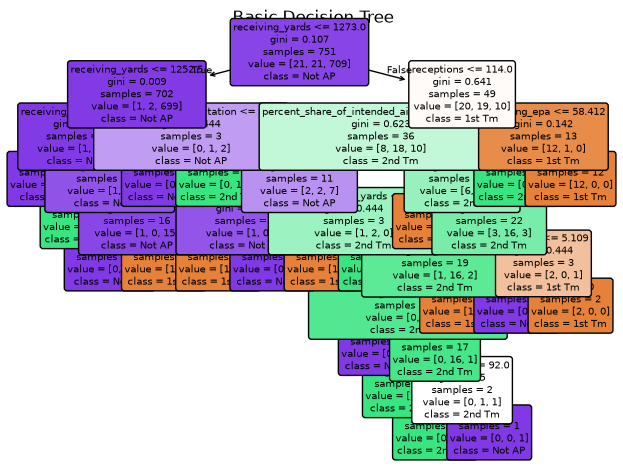

In [43]:
# What are the actual decisions that our decision made? We can investigate that!
plot_tree(
    model,
    filled=True,
    feature_names=X_trn.columns,
    class_names=model.classes_.astype(str),
    rounded=True,
    fontsize=7
)
plt.title("Basic Decision Tree")
plt.tight_layout()
plt.show()

### What are all these metrics??

When we use a decision tree (or any classifier), it's important to understand *how* the model is performing.
Let's make sense of the main metrics you'll see in the classification report:

- **Accuracy**: The simplest metric — it tells us what proportion of predictions our model got right overall.
  > *"Out of all samples, how many did we classify correctly?"*
  - **This seems like the easiest? Why don't we just always use it?**
    - Accuracy can be really misleading!
    - For example, if only a few players each year make an All-Pro team, a model that just predicts "Not All-Pro" for everyone will have high accuracy, but in reality will be a terrible model because it didn't identify any of our 1st or 2nd Team players!
    - Thus, we need some other metrics to see how our models perform on all classes of data, even those that might be rarer 

- **Precision**: For a given class, precision is the fraction of cases we predicted as that class that were actually correct.
  > *"When the model predicts a player is '1st Team', how often is it right?"*
  - We are looking to minimize *false positives*: the model saying a player is a particular class, when in reality they are not

- **Recall** (also called Sensitivity): Recall is the fraction of all actual positive cases (e.g., real '1st Team' All-Pros) that our model correctly identified.
  > *"Of all real '1st Team' All-Pros, how many did our model find?"*
  - We are looking to minimize *false negatives*: the model not correctly identifying a player is of a particular class

- **F1 Score**: The F1 Score balances precision and recall (it's the harmonic mean of the two). It gives a single score that rewards models that achieve both high precision *and* high recall.
  > *"How good is the model at both finding a class and being correct when it does?"*


## III.III: Tuned Decision Tree

Let's try to introduce a bit more detail and nuance into our classification process to see if we can get some better results

In [44]:
# We will specify quite a few more parameters here to see if that improves performance
tuned_model: DecisionTreeClassifier = DecisionTreeClassifier(
    max_depth=5,            # Stops the tree from growing too deep and complex
    min_samples_split=15,   # Requires at least 20 rows to justify making a new split
    min_samples_leaf=10,    # Ensures every final "guess" is based on at least 10 rows
    class_weight='balanced', # Penalize our model for misclassifying minority classes
    random_state=42
)

In [45]:
# Fit our tuned model
tuned_model.fit(X_trn, y_trn)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

In [46]:
# Use this (hopefully) improved model on the testing data
y_pred_tuned = tuned_model.predict(X_tst)
print(classification_report(y_tst, y_pred_tuned))

              precision    recall  f1-score   support

      1st Tm       0.67      1.00      0.80         6
      2nd Tm       0.50      0.50      0.50         6
      Not AP       0.99      0.97      0.98       168

    accuracy                           0.96       180
   macro avg       0.72      0.82      0.76       180
weighted avg       0.96      0.96      0.96       180



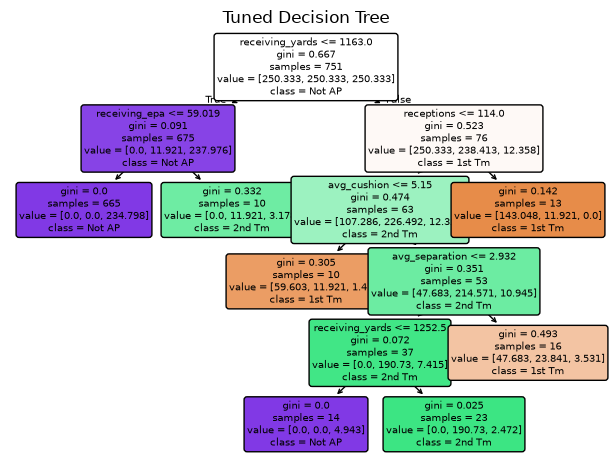

In [47]:
# Basic decision tree plotting using scikit-learn's built-in plot_tree
plot_tree(
    tuned_model,
    filled=True,
    feature_names=X_trn.columns,
    class_names=tuned_model.classes_.astype(str),
    rounded=True,
    fontsize=7
)
plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [48]:
# Let's see what our tuned model predicted the 2024-2025 1st-Team All-Pros to be!
prediction_comparison = test_df
prediction_comparison['model_answer'] = y_pred_tuned
prediction_comparison.loc[prediction_comparison['model_answer'] != prediction_comparison['ap_designation']]

,player_id,season,player_display_name,targets,receptions,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_fumbles_lost,...,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,catch_percentage,avg_yac,avg_expected_yac,avg_yac_above_expectation,ap_designation,model_answer
792,00-0036358,2024,CeeDee Lamb,152,101,1194,6,1190,537,1,...,5.832647,2.885462,7.953092,26.089049,66.447368,5.596634,3.391318,2.205316,2nd Tm,Not AP
804,00-0037238,2024,Drake London,158,100,1271,9,1723,327,0,...,6.697083,2.418622,10.837089,38.229817,63.291139,3.512200,2.760217,0.751983,Not AP,2nd Tm
841,00-0039893,2024,Brian Thomas Jr.,133,87,1282,10,1542,562,0,...,6.161680,3.037410,11.388195,35.006992,65.413534,6.779655,5.503593,1.276063,Not AP,1st Tm
844,00-0039915,2024,Ladd McConkey,112,82,1149,7,1114,390,0,...,5.947009,3.100956,9.869821,26.129772,73.214286,5.108293,4.097037,1.011255,Not AP,2nd Tm
850,00-0031588,2025,Stefon Diggs,102,85,1013,4,871,354,0,...,5.750619,3.042633,8.521078,19.703702,83.333333,4.425882,3.881664,0.544219,Not AP,2nd Tm
881,00-0036963,2025,Amon-Ra St. Brown,172,117,1401,11,1390,570,0,...,6.037081,2.937603,8.379593,38.407361,68.023256,5.151197,4.852615,0.298581,2nd Tm,1st Tm
883,00-0037239,2025,Chris Olave,156,100,1163,9,1841,289,0,...,6.763800,2.926027,11.681474,39.324858,64.102564,2.949100,3.611679,-0.662579,2nd Tm,Not AP
909,00-0039064,2025,Zay Flowers,118,86,1211,5,1204,458,3,...,6.491455,3.519593,9.916102,34.720038,72.881356,5.593140,5.350381,0.242759,Not AP,1st Tm


# Where do we go from here?
This is truly just scraping the iceberg of predictive modeling and there are countless opportunities to extend this analysis further depending on what your interests are?

- **Interested in more data manipulation work?**: Try to change the position from wide receivers to another position (QB, CB, etc...), go through the process of identifying key variables based upon documentation, and also ensure that all of our data is properly formatted based on your desired model
  - Some models required [standardization or normalization](https://www.datacamp.com/tutorial/normalization-vs-standardization), so make sure you are putting the right format of data into your models!
- **Interested more in the modeling portion?**: Try [Random Forests](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_random_forest.html), which are an *ensemble* of multiple decision trees together that can provide more robust reasoning capabilities or [XGBoost](https://medium.com/@imoisharma18/gentle-introduction-of-xgboost-library-2b1ac2669680), which build multiple decision trees sequentially and gradually work to improve the model via Gradient Descent
- Both of these models, while more powerful, will require the optimization of **hyperparameters**, which are the specific knobs that influence how a machine learning model performs. To learn more, look into [hyperparameter optimization](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_hyperparameters.html)
- **Hate this dataset and never want to see it again?**: Totally fair! However, you can take the same ideas of data manipulation and modeling to really any dataset or topic, and the principles should transfer over quite seamlessly. If you need some help, feel free to reach out!